Saving MobilePrice.csv to MobilePrice.csv
Dataset:


,battery_power,ram,int_memory,pc,fc,screen_size,px_height,px_width,four_g,three_g,wifi,bluetooth,price_range
0,670,6287,220,19,18,4.6,577,2169,0,1,0,1,3
1,901,2837,22,2,1,6.2,1160,1520,0,1,1,1,0
2,503,4881,12,8,14,5.8,1426,790,0,1,0,0,0
3,1208,1692,30,13,16,5.2,1448,1476,0,1,0,1,0
4,755,4827,224,12,0,4.8,1752,2455,1,0,0,0,3



Mobile Price Classification Accuracy: 0.8425

Confusion Matrix:
[[89 11  0  0]
 [ 9 76 15  0]
 [ 0 16 81  3]
 [ 0  0  9 91]]


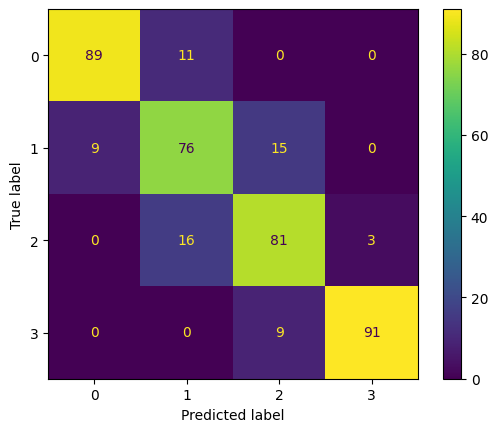

In [1]:
# EXPERIMENT 17: MOBILE PRICE PREDICTION

from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Upload CSV
uploaded = files.upload()

# Read CSV
filename = next(iter(uploaded))
df = pd.read_csv(filename)

print("Dataset:")
display(df.head())

# Features and target
X = df.drop("price_range", axis=1)
y = df["price_range"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nMobile Price Classification Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()